## **SEGMENTAÇÃO DE CLIENTES**

## **Solução de negócio:**

busca-se desenvolver um sistema inteligente que utilize técnicas avançadas de análise de dados para identificar e categorizar grupos de clientes com características semelhantes, utilizando o algoritmo de clustering não-supervisionado: **K-Means**.

O modelo propõe apoiar o time de negócio, visando melhorar significativamente as estratégias de marketing e garantindo que cada cliente receba uma experiência única e relevante.

isso irá direcionar as comunicações e ofertas, permitindo uma abordagem personalizada e eficiente.

## **Bibliotecas:**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## **Dicionário dos dados**

O dataset contém informações de 200 clientes, com os seguintes atributos:

**- CustomerID (variável numérica):** Identificador único atribuído a cada cliente.

**- Gender (variável categórica):** Gênero do cliente.

**- Age (variável numérica):** Idade do cliente.

**- Annual Income-k$ (variável numérica):** Renda anual do cliente em milhares de dólares.

**- Spending Score de 1 a100 (variável numérica):** Pontuação atribuída pelo shopping com base no comportamento e padrão de gastos do cliente.

In [2]:
df = pd.read_csv('../bases/clientes_shopping.csv')

df_original = df.copy()   # backup da base bruta

df = df.drop(columns=['CustomerID'])

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


## **Análise exploratória de dados (EDA)**

Nessa etapa analisa-se o dataset, buscando entender as principais características das variáveis e a distribuição dos dados.

Busca-se identificar padrões através de estatísticas descritivas 

e também verificar a presença de valores ausentes ou inconsistências que precisem ser tratadas.

In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


### o dataset não contém valores faltantes nem duplicados. 

## **Codificação da variável Gender**

In [5]:
#transformando female = 0, male = 1
df['Gender'] = (df['Gender'] == 'Male').astype(int)

In [6]:
# estatísticas descritivas das variáveis numéricas
df.describe()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,0.440000,38.850000,60.560000,50.200000
std,0.497633,13.969007,26.264721,25.823522
min,0.000000,18.000000,15.000000,1.000000
25%,0.000000,28.750000,41.500000,34.750000
50%,0.000000,36.000000,61.500000,50.000000
75%,1.000000,49.000000,78.000000,73.000000
max,1.000000,70.000000,137.000000,99.000000


#### a maioria são **adultos,** média de ~39 anos , mas com clientes mais jovens de 18 anos e mais velhos de 70 anos.

#### a renda anual média de k$ 60.5, com clientes com renda anual menor de k$ 15.0 e clientes com renda anual maior de k$ 137.0.

####  o score interno médio é de 50 pontos, mas com pontuações mínimas de 1 ponto e clientes com pontuações de 99 pontos.

#### os valores do dataset estão dentro da normalidade esperada nesse cenário, sem valores considerados estranhos na base.

## Análise de Gênero (variável categórica)

Gender
0    56.0 %
1    44.0 %
Name: proportion, dtype: object


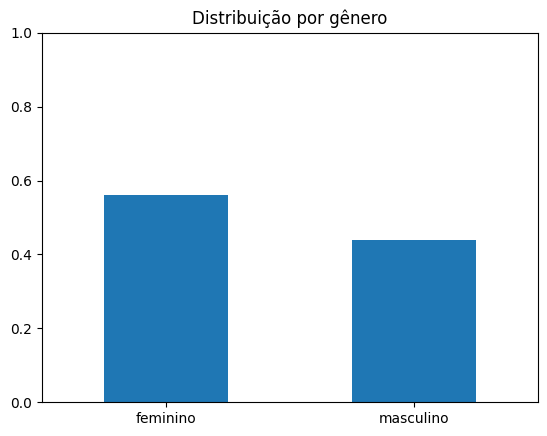

In [7]:
print((df['Gender'].value_counts(normalize=True) * 100).map('{:.1f} %'.format))
df['Gender'].value_counts(normalize=True).plot(kind='bar')


plt.title('Distribuição por gênero')
plt.xticks(rotation=0)
plt.xticks([0,1], ['feminino', 'masculino'])
plt.ylim(0, 1)
plt.ylabel('')
plt.xlabel('')
plt.show()

#### Analisando a distribuição de clientes por gênero, observa-se um maior número de 

#### mulheres, sendo 112 no total, representando 56% da base.

#### enquanto homens são 88 no total, representando 44% da base.

## **Matriz de correlação**

nessa etapa analisamos as relações entre idade, renda e score, ajudando a entender o comportameto dos clientes.

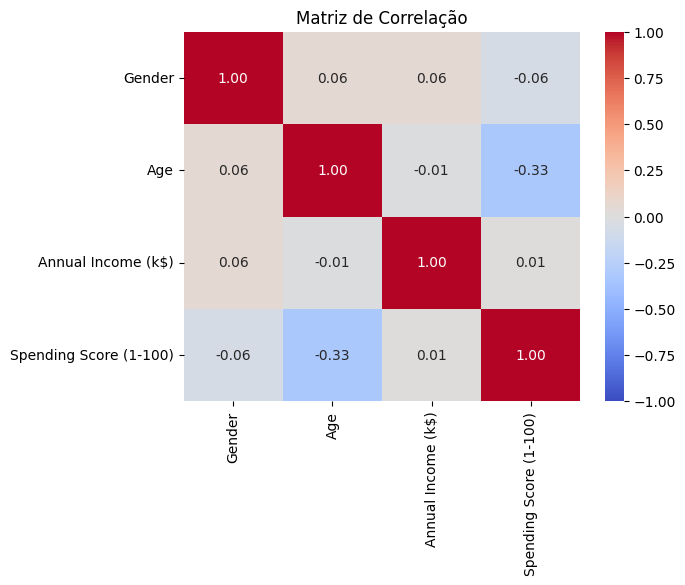

In [8]:
corr = df.corr()


sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmax=1,
    vmin=-1
)
plt.title('Matriz de Correlação')
plt.show()

#### correlação fraca negativa entre idade e score de ≈ -0.33, indica que clientes mais jovens tendem a ter maior spending score,o que faz sentido em contexto de shopping,

#### em termos de correlação linear, as variáveis pouco se relacionam, mas isso não significa que não existam padrões,

#### ou seja, mesmo sem correlação forte, podem existir grupos bem definidos, pois o método de clusterização encontra padrões de agrupamento no espaço multidimensional.

## **Interações entre variáveis numéricas**

nessa etapa busca-se visualizar padrões de comportamento.

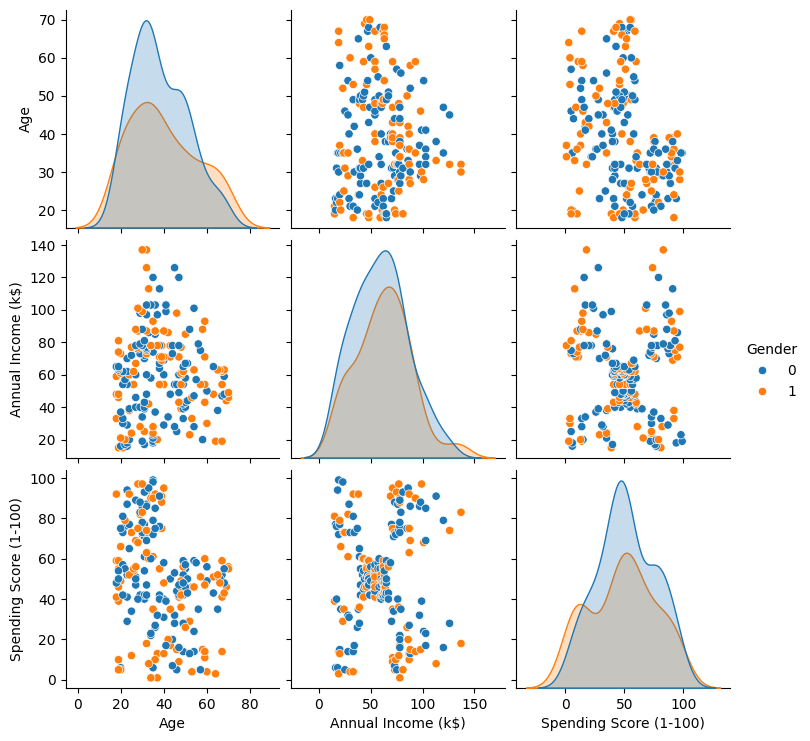

In [9]:
sns.pairplot(df, hue='Gender')

plt.show()

#### não há relação clara entre idade de renda anual, por isso correlação de ~0,01.

#### jovens adultos até 40 anos gastam mais que os indivíduos acima dessa idade.

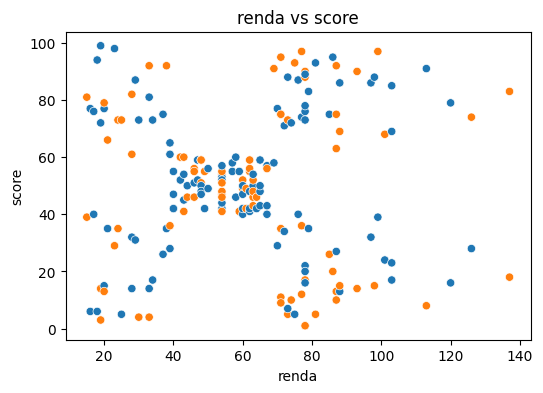

In [10]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender', legend=False)


plt.title('renda vs score')
plt.ylabel('score')
plt.xlabel('renda')
#plt.savefig('../imagens/score_por_renda.png')
plt.show()

#### na relação renda anual e score foi identificado diferentes padrões por faixa de renda e presença de clientes de alto e baixo score em todas as rendas:

#### Perfis:

- clientes de baixo valor: renda baixa + score baixo,

- clientes impulsivos: renda baixa + score alto,

- clientes padrão: renda média + score médio,

- clientes premium: renda alta + score alto,

- clientes com potencial: renda alta + score baixo.

#### conclui-se nesta etapa que mesmo com correlação baixa e dados aparentemente bagunçados, 

#### consegue-se identificar estrutura de clusters latente no espaço renda vs score

## **Conclusões da análise exploratória de dados**

A análise exploratória revelou que a base de clientes apresenta dados consistentes, sem valores ausentes ou outliers evidentes, com distribuições plausíveis para idade, renda anual e score de gasto.

Apesar da baixa correlação, a análise visual por meio de gráficos de dispersão revelou padrões claros de agrupamento, especialmente entre renda anual e spending score, indicando a presença de possíveis segmentos distintos de clientes.

Esses achados sugerem que a base é adequada para aplicação de técnicas de clusterização, como o algoritmo K-Means, com potencial para identificar perfis de clientes com comportamentos distintos de consumo.

## **Pré-processamento**

## **Escalonamento das variáveis**

Como o K-means usa distância (euclidiana), sem escalonamento, a variável com maior escala domina o cálculo da distância, 

resultando em clusters distorcidos.

#### nessa etapa, serão priorizadas as variáveis: **renda e spending score** por representarem diretamente valor e comportamento de consumo, 

#### que são os principais drivers de segmentação no contexto de varejo. 

#### Posteriormente será testado a inclusão da idade como variável complementar para avaliar possíveis refinamentos nos clusters.

In [11]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## **Elbow method** - método do cotovelo

o elbow trás o melhor ponto da inércia, mostrando onde para de trazer ganho relevante, sugerindo o número ideal de k

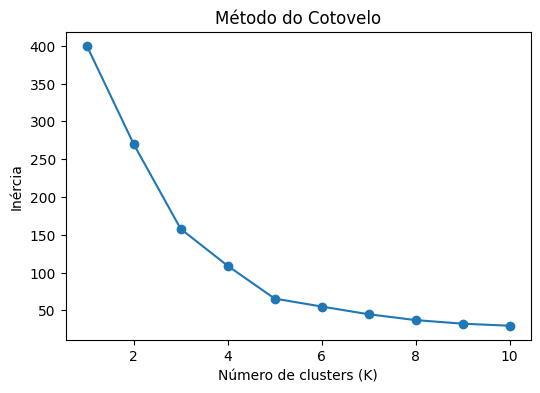

In [12]:
# lista para armazenar as inércias (somando as distâncias dentro dos clusters)
inercia = []

# número de clusters (intervalo de k)
k_range = range(1,11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)             # inercia = erro

#plotando o gráfico
plt.figure(figsize=(6,4))
plt.plot(k_range, inercia, marker='o')
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo")
#plt.savefig('../imagens/elbow_method.png')
plt.show()

#### segundo o método do Cotovelo, indica estabilização da inércia em torno de 5 clusters.

## **Validação quantitativa de clusters**

### **técnica: Silhouette score**

essa métrica avalia duas coisas:

**Coesão:** quão próximos os pontos estão do próprio cluster.

**Separação:** quão longe estão dos outros clusters

In [13]:
# silhouette score
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    print(f"K={k} | Silhouette Score = {score:.2f}")

K=2 | Silhouette Score = 0.32
K=3 | Silhouette Score = 0.47
K=4 | Silhouette Score = 0.49
K=5 | Silhouette Score = 0.55


#### k=5 tem o maior valor (0.55), isso significa clusters mais coesos e melhor separação entre grupos,

#### sendo portanto escolhido como o número ideal de clusters para a segmentação.

## **Modelagem**

## **Treinamento KMeans**

nessa etapa, estrutura-se o treinamento do modelo.

In [14]:
# criando o modelo
kmeans = KMeans(n_clusters=5, n_init=20, random_state=42)

# treinando o k-means
clusters = kmeans.fit_predict(X_scaled)

# adiciona os clusters ao DataFrame
df['cluster'] = clusters

## **Clusters**

nessa etapa visualiza-se os clusters através de um gráfico de dispersão (Scatter)

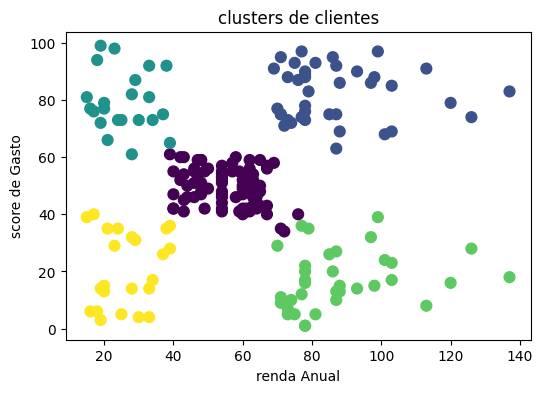

In [19]:
plt.figure(figsize=(6, 4))
plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['cluster'],
    cmap='viridis',
    s=60
)

plt.xlabel('renda Anual')
plt.ylabel('score de Gasto')
plt.title('clusters de clientes')


#plt.savefig('../imagens/cluster_clientes.png')
plt.show()

## **Centróides**

Como o KMeans foi treinado com dados escalados, é preciso voltar os centróides para a escala original para fazer sentido para o negócio.

In [20]:
# Revertendo a padronização para ver os centroides em unidades originais
centroides = scaler.inverse_transform(kmeans.cluster_centers_)

centroids_df = pd.DataFrame(
    centroides,
    columns=['Income', 'Score']
)

centroids_df.map('{:.2f}'.format)

,Income,Score
0,55.30,49.52
1,86.54,82.13
2,25.73,79.36
3,88.20,17.11
4,26.30,20.91


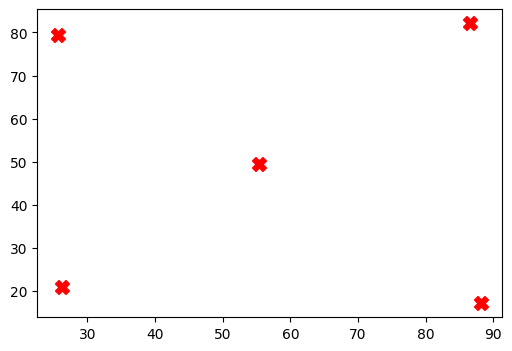

In [23]:
# gráfico
plt.figure(figsize=(6,4))
plt.scatter(
    centroids_df['Income'],
    centroids_df['Score'],
    c='red',
    s=100,
    marker='X',
    label='Centroids'
)

# salvando imagem
#plt.savefig('../imagens/centroids.png')

In [54]:
df['cluster'] = clusters

perfil_clusters = df.groupby('cluster').agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'Age': 'mean',
    'cluster': 'count'
}).rename(columns={
    'Age': 'idade_media',
    'Annual Income (k$)': 'renda_media',
    'Spending Score (1-100)': 'score_medio',
    'cluster': 'qtd_clientes'
}).reset_index()

condicoes =[perfil_clusters['cluster'] == 0,
            perfil_clusters['cluster'] == 1,
            perfil_clusters['cluster'] == 2,
            perfil_clusters['cluster'] == 3,
            perfil_clusters['cluster'] == 4]

rotulos = ['padrao', 'premium', 'impulsivo', 'potencial', 'frio']

perfil_clusters['perfil'] = np.select(condicoes, rotulos, default='nao identificado')

perfil_clusters = perfil_clusters.round({'renda_media': 2})
perfil_clusters['idade_media'] = perfil_clusters['idade_media'].astype(int)
perfil_clusters['score_medio'] = perfil_clusters['score_medio'].astype(int)
perfil_clusters
# fig, ax = plt.subplots(figsize=(6, 4))
# ax.axis('off')
# tabela = ax.table(cellText=perfil_clusters.values, 
#                   colLabels=perfil_clusters.columns, 
#                   loc='center', 
#                   cellLoc='center')
# #tabela.scale(1.2, 1.8) # Dá um "respiro" nas linhas e colunas

# plt.savefig('../imagens/tabela_clusters.png', bbox_inches='tight', dpi=300)
# plt.show() # Sempre depois do savefig!

,cluster,idade_media,renda_media,score_medio,qtd_clientes,perfil
0,0,42,55.30,49,81,padrao
1,1,32,86.54,82,39,premium
2,2,25,25.73,79,22,impulsivo
3,3,41,88.20,17,35,potencial
4,4,45,26.30,20,23,frio


#### grupo 0 - **indivíduos mais velhos de renda média e gasto médio:** clientes de médio padrão e comportamento equilibrado.

#### grupo 1 - **indivíduos adultos de renda alta e gasto alto: grupo que gera mais valor.** Clientes premium.

#### grupo 2 - **indivíduos mais jovens de renda baixa e gasto alto:** indivíduos que gastam muito, mesmo com renda menor.

#### grupo 3 - **indivíduos mais velhos de renda alta e gasto baixo: grupo que precisa de ação de marketing.** Clientes com potencial de gerar crescimento de receita.

#### grupo 4 - **indivíduos mais velhos de renda baixa e gasto baixo: grupo que gera menos valor.** Clientes de baixo valor.

## **Conclusões**

Este projeto teve como objetivo segmentar os clientes de um shopping com base em comportamento de consumo, utilizando técnicas de clusterização (K-Means).

Após análise exploratória completa, foram selecionadas as variáveis renda anual e spending score por apresentarem melhor capacidade de separação e interpretação de negócio.

A escolha de K = 5 clusters foi validada por: Método do Elbow e Métrica de Silhouette Score (≈ 0.55), indicando boa separação entre os grupos.

## **Principais Resultados**

Foram identificados 5 perfis claros de clientes:

Clientes Premium - Alta renda e alto consumo: principal fonte de receita e foco de retenção

Clientes de Alto Potencial - Alta renda, mas baixo consumo: oportunidade de aumento de receita com campanhas direcionadas

Clientes de Alto Consumo com Baixa Renda - Alto engajamento, mesmo com menor poder aquisitivo: público sensível a promoções e parcelamentos

Clientes de Perfil Médio - Consumo e renda moderados:  base estável do negócio

Clientes de Baixo Valor - Baixa renda e baixo consumo:  menor prioridade em investimento de marketing

## **Impacto para o negócio:**

com a segmentação de clientes, foram criadas as seguintes estratégias e planos de ação:

clientes premium : programas VIP, cashback premium e eventos exclusivos.

clientes de alto potencial: campanhas personalizadas, cupons direcionados e CRM.

clientes de alto consumo com baixa renda: estratégias de parcelamento, promoções e programas de fidelidade.

clientes de perfil médio: campanhas genéricas.

clientes de baixo valor: foco em volume e baixo investimento em marketing.

## **Melhorias**

Para evolução do projeto, foram identificadas oportunidades:

- Testar inclusão da variável idade, pois pode melhorar a segmentação comportamental e permite campanhas por faixa etária.

- Testar inclusão da variável gênero codificada para variável numérica, pois permite entender comportamento por sexo.

mas essas inclusões devem ser avaliadas via nova modelagem e comparação de métricas, pois como as poucas variáveis numéricas já separam muito bem os grupos, pode acabar não ajudando.

## **Próximos passos:**

- Testar outros algoritmos para comparar resultados (Hierarchical Clustering ou DBSCAN)

- Aplicação prática (criar personas, simular campanhas e estimar receitas)

- Pipeline de produção (Transformar em função reutilizável e aplicar em novos clientes)

#### Este projeto demonstra como técnicas de Machine Learning não supervisionado podem transformar dados brutos em insights estratégicos de negócio, permitindo decisões mais inteligentes, direcionadas e lucrativas.